<a href="https://colab.research.google.com/github/Mamun-75/Python-For-Data-Science-and-Machine-Learning/blob/main/K_Nearest_Neighbors_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [145]:
df = pd.read_csv("Classified Data")

In [149]:
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [150]:
## consider, we don't know the column name or what tha data means, but we can clearly see that data from different columns are not in a uniform scale, so we need to scale them into a standard scale
## we must apply some form of feature scaling for every distance-based model

In [151]:
from sklearn.preprocessing import StandardScaler ## importing StandardScaler which is a part of sklearn.preprocessing family

In [152]:
scaler = StandardScaler() # making an instance of Standard scaler

In [153]:
scaler.fit(df.drop('TARGET CLASS', axis = 1))  # we fitted the dataset to our scaler, we carefully removed target column

StandardScaler()

In [154]:
# ==============================================================================
# FEATURE SCALING REQUIREMENT CHEAT SHEET
# ==============================================================================
#
# 1. DISTANCE-BASED MODELS (KNN, SVM, K-Means Clustering)
#    -> REQUIRED. These rely on geometric distance (e.g., Euclidean). Unscaled
#       features with large numeric ranges will completely dominate the calculation.
#
# 2. LINEAR & LOGISTIC REGRESSION
#    -> OPTIONAL for basic prediction (learned weights automatically balance ranges).
#    -> REQUIRED if using Gradient Descent (for convergence speed) or
#       Regularization (Lasso/Ridge, to prevent unfair weight penalties).
#
# 3. TREE-BASED MODELS (Decision Trees, Random Forest, XGBoost)
#    -> NOT REQUIRED. These split data sequentially on individual feature
#       thresholds (e.g., if X > 10). The scale of one feature does not affect others.
#
# 4. NEURAL NETWORKS & DEEP LEARNING
#    -> REQUIRED. Networks use Gradient Descent to optimize millions of weights.
#       Unscaled inputs cause erratic gradient updates and prevent convergence.
#
# 5. DIMENSIONALITY REDUCTION (PCA)
#    -> REQUIRED. PCA extracts dimensions with the highest variance. Unscaled
#       features with naturally large numbers will artificially dominate the results.
# ==============================================================================

In [155]:
# we just fitted our data to scaler, data is not transformed yet, lets do it

In [156]:
scaled_features = scaler.transform(df.drop('TARGET CLASS', axis = 1))
# what the transform method does? ot just performs the standardization by centering and scaling

In [157]:
scaled_features

array([[-0.12354188,  0.18590747, -0.91343069, ..., -1.48236813,
        -0.9497194 , -0.64331425],
       [-1.08483602, -0.43034845, -1.02531333, ..., -0.20224031,
        -1.82805088,  0.63675862],
       [-0.78870217,  0.33931821,  0.30151137, ...,  0.28570652,
        -0.68249379, -0.37784986],
       ...,
       [ 0.64177714, -0.51308341, -0.17920486, ..., -2.36249443,
        -0.81426092,  0.11159651],
       [ 0.46707241, -0.98278576, -1.46519359, ..., -0.03677699,
         0.40602453, -0.85567   ],
       [-0.38765353, -0.59589427, -1.4313981 , ..., -0.56778932,
         0.3369971 ,  0.01034996]])

In [158]:
# now we will use this scaled_features variable to recreate a feature dataframe

In [159]:
df_feat = pd.DataFrame(scaled_features, columns = df.columns[:-1])  ## for columns name we took exactly everything from df except the last one

In [160]:
df_feat.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ
0,-0.123542,0.185907,-0.913431,0.319629,-1.033637,-2.308375,-0.798951,-1.482368,-0.949719,-0.643314
1,-1.084836,-0.430348,-1.025313,0.625388,-0.444847,-1.152706,-1.129797,-0.202240,-1.828051,0.636759
2,-0.788702,0.339318,0.301511,0.755873,2.031693,-0.870156,2.599818,0.285707,-0.682494,-0.377850
3,0.982841,1.060193,-0.621399,0.625299,0.452820,-0.267220,1.750208,1.066491,1.241325,-1.026987
4,1.139275,-0.640392,-0.709819,-0.057175,0.822886,-0.936773,0.596782,-1.472352,1.040772,0.276510


<Axes: >

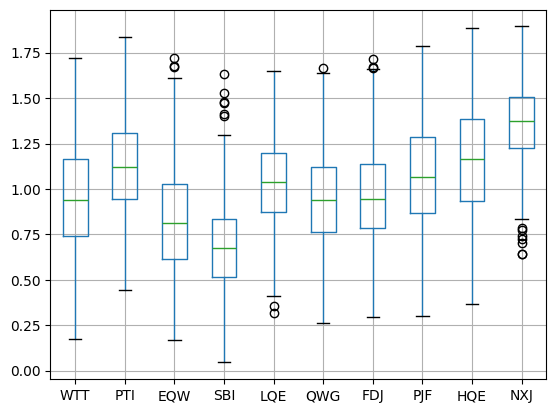

In [164]:
df.drop('TARGET CLASS', axis=1).boxplot()

<Axes: >

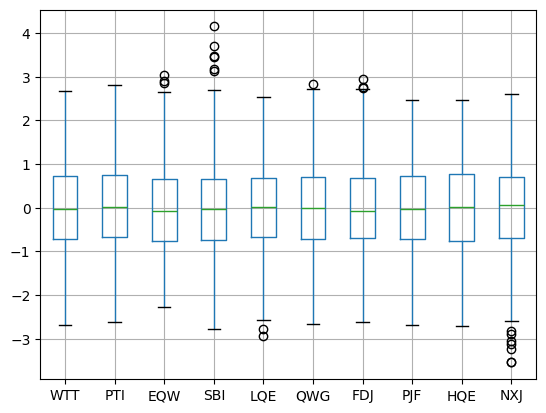

In [165]:
df_feat.boxplot()

In [161]:
# now data is in standard scale and ready for next step

In [162]:
from sklearn.model_selection import train_test_split

In [163]:
X = df_feat
y = df['TARGET CLASS']

In [120]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=101)

In [121]:
## we have completed train test split, now we need to fit in actual model , and then train the model, lets do it

In [122]:
from sklearn.neighbors import KNeighborsClassifier

In [123]:
knn = KNeighborsClassifier(n_neighbors = 1)  # we are starting with number of neighbor =  1

In [124]:
knn.fit(X_train, y_train) ## its fitted , training is completed

KNeighborsClassifier(n_neighbors=1)

In [125]:
# now, lets predict on X_test data , lets see how our model perform

In [126]:
prediction = knn.predict(X_test)

In [127]:
from sklearn.metrics import classification_report , confusion_matrix

In [128]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       159
           1       0.94      0.89      0.92       141

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



In [129]:
print(confusion_matrix(y_test,prediction))

[[151   8]
 [ 15 126]]


In [130]:
### we can see our model is already doing pretty good with n_neighbors = 1,

In [131]:
## we will go ahead and explore if we can sqeeze even more from our model by choosing an even better k value

In [132]:
## ** we will use elbow method to choose a correct k value

In [133]:
error_rate = []   # an empty list , we will iterate with different k values and store their error rate here , and we will find out minimal error rate

In [134]:
for i in range(1,40):

  knn = KNeighborsClassifier(n_neighbors = i)
  knn.fit(X_train, y_train)
  pred_i = knn.predict(X_test)
  error_rate.append(np.mean(pred_i != y_test))



In [135]:
error_rate ## its not super readable for me, so i want to plot this out instead

[np.float64(0.07666666666666666),
 np.float64(0.09),
 np.float64(0.05),
 np.float64(0.07),
 np.float64(0.056666666666666664),
 np.float64(0.05),
 np.float64(0.06666666666666667),
 np.float64(0.06),
 np.float64(0.05),
 np.float64(0.056666666666666664),
 np.float64(0.05333333333333334),
 np.float64(0.04666666666666667),
 np.float64(0.05),
 np.float64(0.056666666666666664),
 np.float64(0.056666666666666664),
 np.float64(0.05),
 np.float64(0.05),
 np.float64(0.04666666666666667),
 np.float64(0.05),
 np.float64(0.05333333333333334),
 np.float64(0.05),
 np.float64(0.05),
 np.float64(0.06333333333333334),
 np.float64(0.056666666666666664),
 np.float64(0.056666666666666664),
 np.float64(0.05),
 np.float64(0.05),
 np.float64(0.04666666666666667),
 np.float64(0.06),
 np.float64(0.05),
 np.float64(0.056666666666666664),
 np.float64(0.04666666666666667),
 np.float64(0.05333333333333334),
 np.float64(0.043333333333333335),
 np.float64(0.04666666666666667),
 np.float64(0.043333333333333335),
 np.flo

Text(0, 0.5, 'Error Rate')

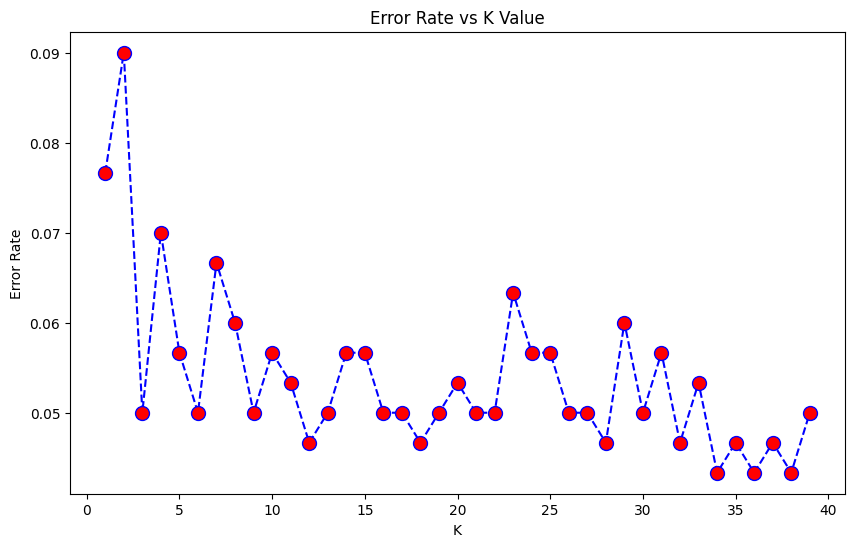

In [136]:
plt.figure(figsize = (10,6))
plt.plot(range(1,40), error_rate, color = 'blue', linestyle = 'dashed', marker = 'o', markerfacecolor = 'red', markersize = 10)
plt.title('Error Rate vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')


In [141]:
## we selected 17 as k value, Because
# K=17 sits in the first stable valley, avoiding the high volatility of smaller K values.
# As an odd number, it prevents deadlock tie-votes during neighbor polling.
# It generalizes well by capturing patterns without over-smoothing like K>30 would.
# We skipped 34, 36, and 38 because checking that many neighbors makes the model too slow for real world implementation like mobile apps.
# Huge K values also blur the data patterns, making predictions less accurate on new data.
## elbow method is amazing!

In [142]:
 knn = KNeighborsClassifier(n_neighbors=17)
 knn.fit(X_train, y_train)
 pred = knn.predict(X_test)
 print(classification_report(y_test, pred))
 print('\n')
 print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       159
           1       0.96      0.94      0.95       141

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



[[153   6]
 [  9 132]]
